In [75]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

In [76]:
import importlib
import helpers_louis
importlib.reload(helpers_louis)

<module 'helpers_louis' from '/Users/louistschanz/Documents/EPFL/MA4/MLBD_2026/helpers_louis.py'>

## Main research question
To what extent do students' written responses, feedback quality, and chatbot engagement patterns reflect their level of understanding and predict academic performance?

## Sub-question 1
How do the linguistic and semantic characteristics of students' written responses relate to their performance across essay and text comprehension assessments?

## Part 1 — Essay-based analysis
Can simple linguistic surface features extracted from students' essays predict essay performance?

## First prediction task
We start with a focused regression task on `essay_results.csv`.

- **Input:** essay metadata and engineered features extracted from the raw essay text
- **Target:** an essay assessment score, initially `structure__coherence`
- **Goal:** test whether simple observable linguistic characteristics of essays already carry predictive signal about writing quality

## Why this first step?
This first step provides a clean baseline before moving to:
1. richer semantic text features
2. text comprehension responses from `text_results.csv`
3. a broader comparison across assessment types

In [37]:
# Directory
print("Python working directory:", os.getcwd())

data_dir = './data'
assert os.path.isdir(data_dir), f"File not found: {data_dir}" # check files exist

Python working directory: /Users/louistschanz/Documents/EPFL/MA4/MLBD_2026


In [38]:

essay_results = pd.read_csv('{}/essay_results.csv'.format(data_dir))

In [52]:
# dataframe de travail
df_clean = essay_results[["course", "text_type", "text", "structure__coherence"]].copy()
df_clean = df_clean.dropna(subset=["course", "text_type", "text", "structure__coherence"]).copy()

# features engeneering
df_clean["word_count"] = df_clean["text"].apply(helpers_louis.word_count)
df_clean["char_count"] = df_clean["text"].apply(helpers_louis.char_count)
df_clean["sentence_count"] = df_clean["text"].apply(helpers_louis.sentence_count)
df_clean["avg_sentence_length"] = df_clean["text"].apply(helpers_louis.avg_sentence_length)
df_clean["avg_word_length"] = df_clean["text"].apply(helpers_louis.avg_word_length)
df_clean["lexical_diversity"] = df_clean["text"].apply(helpers_louis.lexical_diversity)
df_clean["comma_count"] = df_clean["text"].apply(helpers_louis.comma_count)
df_clean["semicolon_count"] = df_clean["text"].apply(helpers_louis.semicolon_count)
df_clean["colon_count"] = df_clean["text"].apply(helpers_louis.colon_count)
df_clean["exclamation_count"] = df_clean["text"].apply(helpers_louis.exclamation_count)
df_clean["question_count"] = df_clean["text"].apply(helpers_louis.question_count)
df_clean["long_word_ratio"] = df_clean["text"].apply(helpers_louis.long_word_ratio)


# ===== 4) X / y =====
feature_cols = [
    "course",
    "text_type",
    "word_count",
    "char_count",
    "sentence_count",
    "avg_sentence_length",
    "avg_word_length",
    "lexical_diversity",
    "comma_count",
    "semicolon_count",
    "colon_count",
    "exclamation_count",
    "question_count",
    "long_word_ratio",
]

X = df_clean[feature_cols].copy()
y = df_clean["structure__coherence"].copy()

print(df_clean.shape)
print(X.head())
print(y.head())

(10065, 16)
   course   text_type  word_count  char_count  sentence_count  \
0    5447  erzaehlung         491        3048              41   
1    5447  erzaehlung         579        3542              60   
2    5447  erzaehlung         310        1897              25   
3    5447  erzaehlung         582        3686              60   
4    5447  erzaehlung          96         569               4   

   avg_sentence_length  avg_word_length  lexical_diversity  comma_count  \
0             11.97561         4.997963           0.584521           24   
1              9.65000         4.744387           0.426598           37   
2             12.40000         4.948387           0.561290           18   
3              9.70000         4.970790           0.426117           37   
4             24.00000         4.802083           0.750000            9   

   semicolon_count  colon_count  exclamation_count  question_count  \
0                0            1                  3               3   
1     

In [ ]:
cat_cols = ["course", "text_type"]
num_cols = [c for c in feature_cols if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        )
    ]
)

mlp_model_clean = Pipeline([
    ("prep", preprocessor),
    ("reg", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

mlp_model_clean.fit(X_train, y_train)
y_pred = mlp_model_clean.predict(X_test)

In [54]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("n_iter_ =", mlp_model_clean.named_steps["reg"].n_iter_)
print("final_loss =", mlp_model_clean.named_steps["reg"].loss_)

MAE : 0.9843959924265486
RMSE: 1.2713752802693878
R2  : 0.3279084200774921
n_iter_ = 60
final_loss = 0.7887518751372673


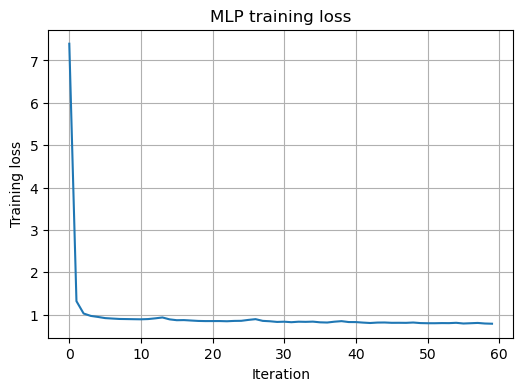

In [55]:

plt.figure(figsize=(6,4))
plt.plot(mlp_model_clean.named_steps["reg"].loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.title("MLP training loss")
plt.grid(True)
plt.show()

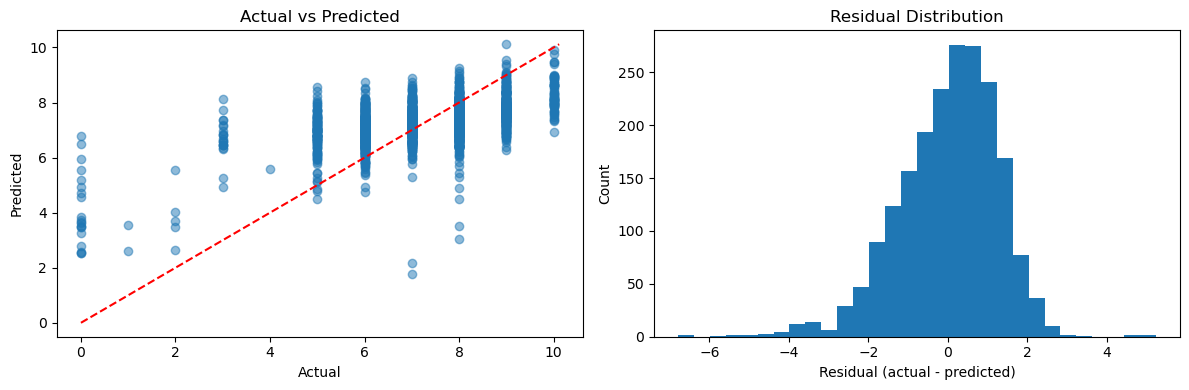

In [56]:
residuals = y_test - y_pred

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax[0].plot(lims, lims, "r--")
ax[0].set_title("Actual vs Predicted")
ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")

ax[1].hist(residuals, bins=30)
ax[1].set_title("Residual Distribution")
ax[1].set_xlabel("Residual (actual - predicted)")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [57]:
pred_df = X_test.copy()
pred_df["y_true"] = y_test.values
pred_df["y_pred"] = y_pred
pred_df["abs_err"] = np.abs(pred_df["y_true"] - pred_df["y_pred"])

print("Top errors by course:")
display(pred_df.groupby("course")["abs_err"].mean().sort_values(ascending=False).head(10))

print("Top errors by text_type:")
display(pred_df.groupby("text_type")["abs_err"].mean().sort_values(ascending=False).head(10))

Top errors by course:


course
5447    0.990491
3301    0.974700
Name: abs_err, dtype: float64

Top errors by text_type:


text_type
bericht         1.030466
erzaehlung      1.008512
beschreibung    0.916116
eroerterung     0.868679
Name: abs_err, dtype: float64

## Part 2 — Essay analysis with richer semantic features
After building a first baseline with simple surface-level linguistic features, we extend the essay analysis by incorporating richer semantic representations of the text.

We ask the following question:

**Do richer semantic text features improve the prediction of essay performance compared with simple linguistic surface features alone?**

In this second step, we keep the same essay-based setting and the same prediction framework, but we move from basic handcrafted features toward more informative text representations.

The goal is to evaluate whether semantic information contained in students' essays provides additional predictive value for essay assessment outcomes.

In [79]:
german_stopwords = [
    "aber", "als", "am", "an", "auch", "auf", "aus", "bei", "bin", "bis",
    "bist", "da", "dadurch", "daher", "darum", "das", "daß", "dass", "dein",
    "deine", "dem", "den", "der", "des", "dessen", "deshalb", "die", "dies",
    "dieser", "dieses", "doch", "dort", "du", "durch", "ein", "eine", "einem",
    "einen", "einer", "eines", "er", "es", "euer", "eure", "für", "hatte",
    "hatten", "hattest", "hattet", "hier", "hinter", "ich", "ihr", "ihre",
    "im", "in", "ist", "ja", "jede", "jedem", "jeden", "jeder", "jedes",
    "jener", "jenes", "jetzt", "kann", "kannst", "können", "könnt", "machen",
    "mein", "meine", "mit", "muß", "mußt", "musst", "müssen", "müsst",
    "nach", "nachdem", "nein", "nicht", "nun", "oder", "seid", "sein",
    "seine", "sich", "sie", "sind", "soll", "sollen", "sollst", "sollt",
    "sonst", "soweit", "sowie", "und", "unser", "unsere", "unter", "vom",
    "von", "vor", "wann", "warum", "was", "weiter", "weitere", "wenn",
    "wer", "werde", "werden", "werdet", "weshalb", "wie", "wieder", "wieso",
    "wir", "wird", "wirst", "wo", "woher", "wohin", "zu", "zum", "zur",
    "über"
]

In [80]:
# data selection for part 2
df_semantic = essay_results[["course", "text_type", "text", "structure__coherence"]].copy()
df_semantic = df_semantic.dropna(subset=["course", "text_type", "text", "structure__coherence"]).copy()

df_semantic["text_clean"] = df_semantic["text"].apply(helpers_louis.clean_german_essay_text)

X = df_semantic[["course", "text_type", "text_clean"]]
y = df_semantic["structure__coherence"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
#Preprocessing
text_col = "text_clean"
cat_cols = ["course", "text_type"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                stop_words=german_stopwords,
                ngram_range=(1, 1),
                min_df=3,
                max_df=0.90,
                max_features=5000,
                sublinear_tf=True,
                token_pattern=r"(?u)\b[a-zA-ZäöüÄÖÜß]{2,}\b"
            ),
            text_col
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        )
    ],
    remainder="drop"
)


In [87]:
# model
ridge_model = Pipeline([
    ("prep", preprocessor),
    ("reg", Ridge(alpha=1.0))
])

In [88]:
# model fitting
ridge_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [89]:
# model evaluation
y_pred = ridge_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.9016309576099202
RMSE: 1.257670405756982
R2  : 0.34232003556983537


In [90]:
tfidf = ridge_model.named_steps["prep"].named_transformers_["text"]
feature_names = tfidf.get_feature_names_out()

print("nb text features:", len(feature_names))
print(feature_names[:100])

nb text features: 5000
['aarau' 'ab' 'abend' 'abendessen' 'abends' 'abenteuer' 'aberdeen'
 'abfall' 'abgeben' 'abgelegenen' 'abgelenkt' 'abgemacht' 'abgeschafft'
 'abgeschlossen' 'abgesehen' 'abholen' 'abhängig' 'abkürzung'
 'abkürzungen' 'ablauf' 'ablenken' 'ablenkung' 'abrupt' 'abschied'
 'abschliessend' 'abschluss' 'abseits' 'absichtlich' 'absolut' 'abstand'
 'abwechslung' 'ach' 'acht' 'achten' 'achterbahn' 'achterbahnen' 'achtung'
 'adler' 'adrenalin' 'adresse' 'affe' 'affen' 'agent' 'ah' 'ahmed' 'ahnte'
 'ahnung' 'aisha' 'akku' 'aktion' 'aktiv' 'aktivitäten' 'akzeptieren'
 'akzeptierte' 'al' 'alarm' 'albtraum' 'alexander' 'alexandra' 'algen'
 'alien' 'aliens' 'alkohol' 'all' 'alle' 'allein' 'alleine' 'allem'
 'allen' 'aller' 'allerbesten' 'allerbester' 'allerdings' 'alles'
 'allgemein' 'alls' 'alltag' 'allzu' 'also' 'alt' 'alte' 'alten' 'alter'
 'alternative' 'altes' 'ampeln' 'anblick' 'and' 'andere' 'anderem'
 'anderen' 'anderer' 'andererseits' 'anderes' 'andern' 'anders'
 'ander

## Interim result for Step 2
A German word-level TF-IDF representation provides some predictive signal for essay coherence, but it remains substantially weaker than the surface-feature baseline from Steo 1.

This suggests that, for the target `structure__coherence`, structural and stylistic properties of the text are more informative than lexical content alone.

## Part 3 — Text comprehension analysis
To answer Sub-question 1 more fully, we now extend the analysis from essays to text comprehension assessments.

In this part, we study whether linguistic characteristics extracted from students' written answers in `text_results.csv` are related to their performance on text comprehension tasks.

The goal is to apply a similar prediction framework as in the essay analysis, but on a different assessment type:
- **Input:** written student answers and simple engineered text features
- **Target:** normalized performance score (`points / max_points`)

This allows us to examine whether the relationship between writing features and performance generalizes beyond essays to text comprehension responses.

In [91]:

# ===== load =====
text_results = pd.read_csv('{}/text_results.csv'.format(data_dir))

# check colonnes
print(text_results.shape)
print(text_results.columns.tolist())
text_results.head()

(67351, 11)
['Unnamed: 0', 'user_id', 'course_id', 'exam_id', 'session_id', 'question_id', 'points', 'max_points', 'answer', 'feedback', 'timestamp']


,Unnamed: 0,user_id,course_id,exam_id,session_id,question_id,points,max_points,answer,feedback,timestamp
0,0,4046,5009,11,6947e1eba83c7eae820f90f3,11-0,1,1.0,NaN,Nur 1 Punkt für: Frau Egli,1729603799
1,1,4046,5009,11,6947e1eba83c7eae820f90f3,11-1,1,1.0,NaN,Nur 1 Punkt für: die Besitzerin des roten Dame...,1729603799
2,2,4046,5009,11,6947e1eba83c7eae820f90f3,11-2,0,1.0,NaN,verschiedene Arbeitgeber,1729603799
3,3,4046,5009,11,6947e1eba83c7eae820f90f3,11-3,1,1.0,NaN,'Die Polizei' ist korrekt.,1729603799
4,4,4046,5009,11,6947e1eba83c7eae820f90f3,11-4,1,4.0,NaN,"Pro Adjektiv 1 Punkt, 1 Punkt Abzug für jedes ...",1729603799


In [92]:
# Preprocessing
df_text_clean = text_results[[
    "course_id",
    "answer",
    "points",
    "max_points"
]].copy()

# drop missing / invalid target rows
df_text_clean = df_text_clean.dropna(subset=["course_id", "answer", "points", "max_points"]).copy()
df_text_clean = df_text_clean[df_text_clean["max_points"] > 0].copy()

# normalized target
df_text_clean["relative_score"] = df_text_clean["points"] / df_text_clean["max_points"]

print(df_text_clean.shape)
df_text_clean.head()

(14115, 5)


,course_id,answer,points,max_points,relative_score
50099,2115,"{'studentAnswer': 'Kosovo', 'points': 1, 'resp...",1,1.0,1.0
50100,2115,"{'studentAnswer': 'Weiblich', 'points': 1, 're...",1,1.0,1.0
50101,2115,"{'studentAnswer': '10-41', 'points': 1, 'respo...",1,1.0,1.0
50102,2115,"{'studentAnswer': 'Vor 29 Jahren', 'points': 0...",0,1.0,0.0
50103,2115,"{'studentAnswer': 'Leichte umarmung, sarah spr...",1,2.0,0.5


In [94]:

# same featuring engeerining than Part1
df_text_clean["word_count"] = df_text_clean["answer"].apply(helpers_louis.word_count)
df_text_clean["char_count"] = df_text_clean["answer"].apply(helpers_louis.char_count)
df_text_clean["sentence_count"] = df_text_clean["answer"].apply(helpers_louis.sentence_count)
df_text_clean["avg_sentence_length"] = df_text_clean["answer"].apply(helpers_louis.avg_sentence_length)
df_text_clean["avg_word_length"] = df_text_clean["answer"].apply(helpers_louis.avg_word_length)
df_text_clean["lexical_diversity"] = df_text_clean["answer"].apply(helpers_louis.lexical_diversity)
df_text_clean["comma_count"] = df_text_clean["answer"].apply(helpers_louis.comma_count)
df_text_clean["semicolon_count"] = df_text_clean["answer"].apply(helpers_louis.semicolon_count)
df_text_clean["colon_count"] = df_text_clean["answer"].apply(helpers_louis.colon_count)
df_text_clean["exclamation_count"] = df_text_clean["answer"].apply(helpers_louis.exclamation_count)
df_text_clean["question_count"] = df_text_clean["answer"].apply(helpers_louis.question_count)
df_text_clean["long_word_ratio"] = df_text_clean["answer"].apply(helpers_louis.long_word_ratio)

feature_cols = [
    "course_id",
    "word_count",
    "char_count",
    "sentence_count",
    "avg_sentence_length",
    "avg_word_length",
    "lexical_diversity",
    "comma_count",
    "semicolon_count",
    "colon_count",
    "exclamation_count",
    "question_count",
    "long_word_ratio",
]

X = df_text_clean[feature_cols].copy()
y = df_text_clean["relative_score"].copy()

print(X.head())
print(y.head())
print(y.describe())

       course_id  word_count  char_count  sentence_count  avg_sentence_length  \
50099       2115          55         396               7             7.857143   
50100       2115          34         267               6             5.666667   
50101       2115          46         304               6             7.666667   
50102       2115          56         375               5            11.200000   
50103       2115          93         660               8            11.625000   

       avg_word_length  lexical_diversity  comma_count  semicolon_count  \
50099         5.636364           0.836364            5                0   
50100         6.176471           0.911765            2                0   
50101         5.043478           0.913043            5                0   
50102         5.196429           0.839286            8                0   
50103         5.731183           0.763441           14                0   

       colon_count  exclamation_count  question_count  long_wo

In [95]:
cat_cols = ["course_id"]
num_cols = [c for c in feature_cols if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        )
    ]
)

mlp_text_model = Pipeline([
    ("prep", preprocessor),
    ("reg", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

mlp_text_model.fit(X_train, y_train)
y_pred = mlp_text_model.predict(X_test)


MAE : 0.18066669359596152
RMSE: 0.2574996266043827
R2  : 0.6459872226022738
n_iter_ = 109
final_loss = 0.028693992989494262


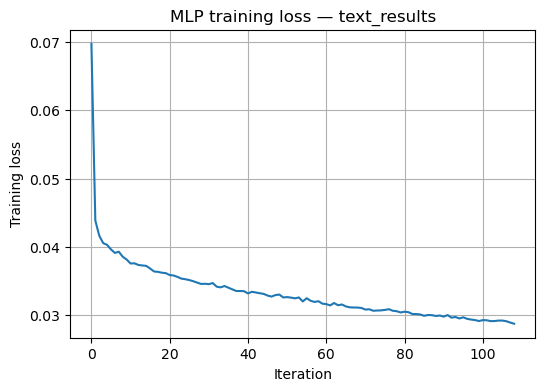

In [96]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("n_iter_ =", mlp_text_model.named_steps["reg"].n_iter_)
print("final_loss =", mlp_text_model.named_steps["reg"].loss_)

plt.figure(figsize=(6,4))
plt.plot(mlp_text_model.named_steps["reg"].loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.title("MLP training loss — text_results")
plt.grid(True)
plt.show()

## Interim result after Part 3
Simple engineered linguistic features extracted from students' written responses provide substantial predictive signal for both essay assessment outcomes and text comprehension performance.

The results suggest that observable properties of student writing are meaningfully related to performance across both assessment types, although the predictive strength is higher for essay scoring than for text comprehension.